## First select the appropriate options

In [11]:
### Bone to predict:
BONE = 'radius'

### Change to older model that does not record the CT_PO:
OLDER_MACHINE = False

### Add mechanography features:
ADD_MECHANOGRAPHY = False

### Remove Miki
REMOVE_MIKI = True

### Use the clustering method:
USE_CLUSTERING = True

### Balance class weights
BALANCE_WEIGHTS = False

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import pickle

from binarize_grades import binarize_grades

In [13]:
raw_motion_data = pd.read_excel("data/Motion full matched_for_olga.xlsx", header=1)
motion_data = raw_motion_data.replace('-', np.nan)

/tmp/ipykernel_2650610/313659671.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  motion_data = raw_motion_data.replace('-', np.nan)


## Handle the grader columns

In [14]:
grader_column = f'MG_{BONE}_rounded mean'

if REMOVE_MIKI:
    grader_column = f'MG_{BONE}_rounded mean no Miki'
    # add column that combines the two other graders via a mean
    graders = ['Alex', 'Felix']
    if BONE == 'tibia':
        graders = [f"{x}.1" for x in graders]
    motion_data[grader_column] = motion_data[graders].mean(axis=1)
    motion_data[grader_column] = motion_data[grader_column].round()
    motion_data[grader_column] = motion_data[grader_column].astype(int)

## Prepare the datasets

In [15]:
radius_columns = ['Tt.BMD', 'Tt.Ar', 'Tb.BMD', 'BV/TV', 'Tb.N', 'Tb.Th', 'Tb.Sp', 'Tb.1/N.SD', 'Tb.Ar', 'Ct.BMD', 'Ct.Th', 'Ct.Po', 'Ct.Po.Dm', 'Ct.Pm', 'Ct.Ar']
mechanography_columns = ['GRF', 'f max', 'f max rel', 'CRT tpr', 'PLEO', 'PLEC', 'EAEO', 'EAEC', 'VREO', 'VREC']
remove_features = []

radius_columns = [x for x in radius_columns if x not in remove_features]

if OLDER_MACHINE:
    # remove all rows where Ct.Po and Ct.Po.Dm are present
    motion_data = motion_data[motion_data['Ct.Po'].isna()]
    radius_columns.remove('Ct.Po')
    radius_columns.remove('Ct.Po.Dm')

tibia_columns = [f"{x}.1" for x in radius_columns]

if ADD_MECHANOGRAPHY:
    radius_columns += mechanography_columns
    tibia_columns += mechanography_columns

motion_data[radius_columns] = motion_data[radius_columns].astype(float)
motion_data[tibia_columns] = motion_data[tibia_columns].astype(float)
motion_data[tibia_columns].head()

# drop NaN rows
motion_data = motion_data.dropna(subset=radius_columns + tibia_columns)

# print the counts of each class
print(motion_data[grader_column].value_counts())
print(f"Total: {len(motion_data)}")

MG_radius_rounded mean no Miki
2    226
1    132
4     84
3     51
5      7
Name: count, dtype: int64
Total: 500


In [16]:
if not USE_CLUSTERING:
    # Method 1 of binarizing

    # binarize the labels by combining grade 1,2,3 and 4,5
    motion_data[grader_column] = motion_data[grader_column].replace({1: 0, 2: 0, 3: 0, 4: 1, 5: 1})
    print(motion_data[grader_column].value_counts())
    grade_col_name = grader_column
else:
    # Method 2 of binarizing
    # apply clustering the grade 3
    grades = motion_data[grader_column]
    motion_data = motion_data[radius_columns] if BONE == 'radius' else motion_data[tibia_columns]
    motion_data, zero_center, one_center = binarize_grades(motion_data, grades, return_centers=True)
    print(motion_data['cluster'].value_counts())
    grade_col_name = 'cluster'

    # save the centers for later use
    machine = 'old' if OLDER_MACHINE else 'new'
    with open(f"data/{BONE}_{machine}_centers.pkl", "wb") as f:
        pickle.dump((zero_center, one_center), f)

Cluster 0: 358
Cluster 1: 91
Unassigned: 51
cluster
0    400
1    100
Name: count, dtype: int64


In [17]:
# 17 -> 5 to good, 12 to bad # tibia 1
# 16 -> 8 to good, 8 to bad # tibia 2
# 51 -> 42 to good, 9 to bad # radius 2
# 66 -> 33 to good, 33 to bad # radius 1

In [18]:
# put the radius columns in a np array
X = motion_data[radius_columns].values if BONE == 'radius' else motion_data[tibia_columns].values
y = motion_data[grade_col_name].values
print(X.shape, y.shape)

(500, 15) (500,)


In [19]:
scaler = StandardScaler()

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# save the scaler for later use
with open(f"models/{BONE}_{'XCT1' if OLDER_MACHINE else 'XCT2'}_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

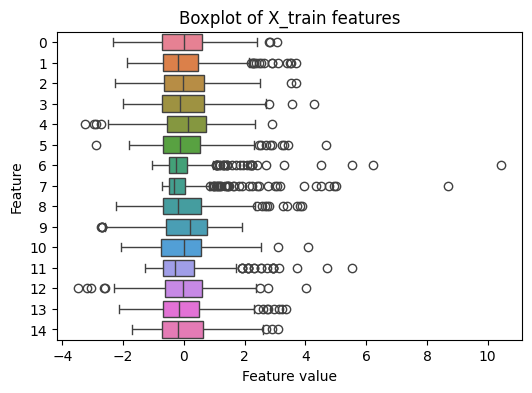

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# print X_train boxplot for each column
plt.figure(figsize=(6, 4))
sns.boxplot(data=X_train, orient='h')
plt.title('Boxplot of X_train features')
plt.xlabel('Feature value')
plt.ylabel('Feature')
plt.show()

In [21]:
scaler.mean_

array([2.50695429e+02, 2.99441143e+02, 1.19142286e+02, 1.74302857e-01,
       1.17617714e+00, 2.27040000e-01, 9.33114286e-01, 4.80400000e-01,
       2.48283714e+02, 8.32140000e+02, 8.93520000e-01, 7.39142857e-03,
       1.75848571e-01, 7.36345714e+01, 5.51188571e+01])

In [22]:
# get the values of the scaler 
columns = radius_columns if BONE == 'radius' else tibia_columns
with open(f"data/{BONE}_{'XCT1' if OLDER_MACHINE else 'XCT2'}_scaler_values.csv", "w") as f:
    f.write(f",".join(columns + ['value', 'bone', 'xct']) + "\n")
    f.write(f",".join([f"{x:.8f}" for x in scaler.mean_]) + f",mean,{BONE},{'XCT1' if OLDER_MACHINE else 'XCT2'}\n")
    f.write(f",".join([f"{x:.8f}" for x in scaler.scale_]) + f",var,{BONE},{'XCT1' if OLDER_MACHINE else 'XCT2'}\n")

In [24]:
weights = None if not BALANCE_WEIGHTS else 'balanced'
model = LogisticRegression(penalty='l1', solver='saga', l1_ratio=1, max_iter=1000, class_weight=weights)
model.fit(X_train, y_train)

/home/elias/.conda/envs/ProBone/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(


LogisticRegression(l1_ratio=1, max_iter=1000, penalty='l1', solver='saga')

Accuracy: 0.8266666666666667
Sensitivity: 0.3870967741935484
Specificity: 0.9411764705882353
Precision: 0.8549618320610687


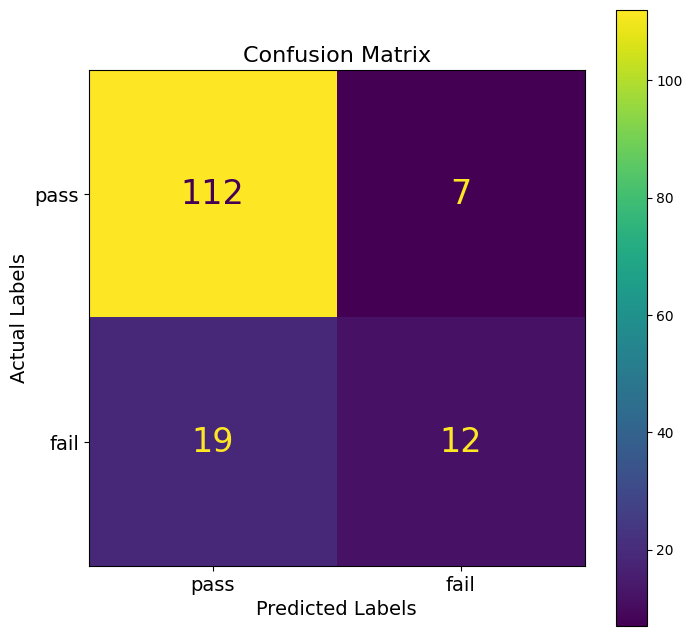

In [25]:
accuracy = model.score(X_test, y_test)
print(f'Accuracy: {accuracy}')
# make confusion matrix
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

# calculate false-positive rate, false-negative rate
tn, fp, fn, tp = cm.ravel()
print(f'Sensitivity: {tp / (tp + fn)}')
print(f'Specificity: {tn / (tn + fp)}')
print(f'Precision: {tn / (tn + fn)}')


labels = ['pass', 'fail']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

# Plot with customization
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap='viridis', values_format='d', text_kw={'fontsize': 24})  # Use d for integer formatting
ax.tick_params(axis='both', which='major', labelsize=14)

# Increase font size for labels and title
plt.xlabel('Predicted Labels', fontsize=14)
plt.ylabel('Actual Labels', fontsize=14)
plt.title('Confusion Matrix', fontsize=16)

plt.show()

In [26]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

## Extract the importance of each feature

In [27]:
coefficients = model.coef_  # Shape will be (n_classes, n_features)
feature_importance = np.abs(coefficients).mean(axis=0) 
coefficients[0]

array([ 0.        , -0.07269662,  0.        , -2.86874319,  2.10919845,
        1.39870286, -1.26678596,  1.47910082, -0.15464419, -0.99319338,
        0.49056581, -0.40174854, -0.4802428 , -0.47360208,  0.        ])

In [28]:
intercept = model.intercept_  # Shape will be (n_classes,)
intercept

array([-1.91626145])

In [29]:
feature_names = radius_columns if BONE == 'radius' else tibia_columns
for i in range(len(feature_names)):
    print(f"{i}. {feature_names[i]}: {coefficients[0][i]}")

0. Tt.BMD: 0.0
1. Tt.Ar: -0.0726966243384488
2. Tb.BMD: 0.0
3. BV/TV: -2.8687431921913236
4. Tb.N: 2.109198447140519
5. Tb.Th: 1.3987028587881791
6. Tb.Sp: -1.2667859551027532
7. Tb.1/N.SD: 1.4791008234719643
8. Tb.Ar: -0.1546441912171849
9. Ct.BMD: -0.9931933799945284
10. Ct.Th: 0.4905658147301724
11. Ct.Po: -0.40174854051814657
12. Ct.Po.Dm: -0.48024280096489985
13. Ct.Pm: -0.4736020781354811
14. Ct.Ar: 0.0


In [30]:
with open(f"data/coefficients_{'XCT1' if OLDER_MACHINE else 'XCT2'}_{BONE}{'_balanced' if BALANCE_WEIGHTS else ''}.csv", "w") as f:
    f.write(f"feature,coefficient\n")
    for i in range(len(feature_names)):
        f.write(f"{feature_names[i]},{coefficients[0][i]:.8f}\n")

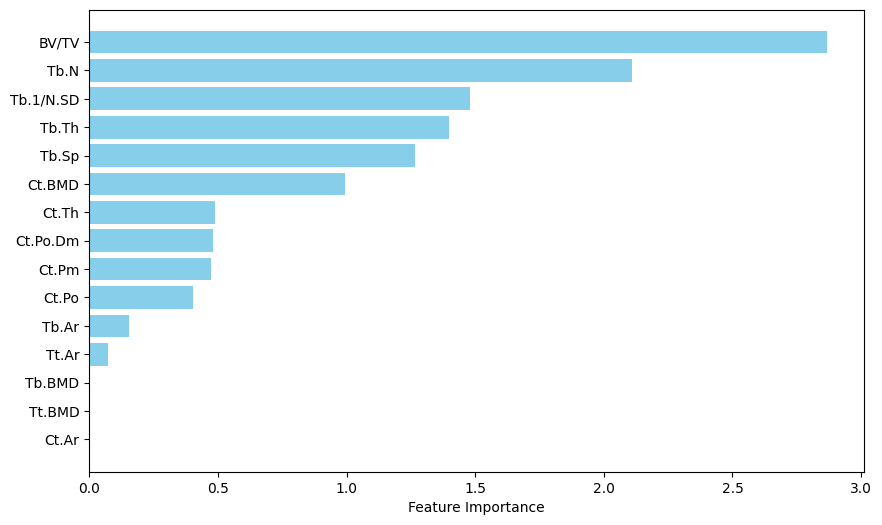

In [31]:
if BONE == 'tibia':
    feature_names = tibia_columns
else:
    feature_names = radius_columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
})

XCT = 'XCT1' if OLDER_MACHINE else 'XCT2'
balance = '_balanced' if BALANCE_WEIGHTS else ''

# Sort by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Feature Importance')
plt.gca().invert_yaxis()
plt.savefig(f'figures/feature_importance_{XCT}_{BONE}{balance}.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [32]:
importance_df.to_csv(f'data/feature_importance_{XCT}_{BONE}{balance}.csv', index=False)

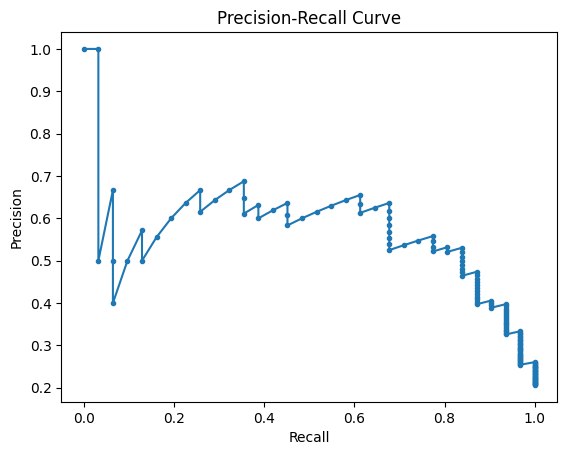

In [33]:
y_pred_proba = model.predict_proba(X_test)
y_pred_proba_pos = y_pred_proba[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba_pos)

plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

In [34]:
SAVE=False
if SAVE:
    # save the model as a pickle file
    import pickle
    machine = 'old' if OLDER_MACHINE else 'new'
    balanced = 'balanced_' if BALANCE_WEIGHTS else ''
    with open(f"models/{BONE}_{machine}_{balanced}model.pkl", 'wb') as f:
        pickle.dump(model, f)

(array([4., 0., 4., 3., 1., 0., 1., 1., 0., 2., 1., 1., 2., 1., 0., 1., 1.,
        2., 0., 1.]),
 array([0.51145447, 0.5339306 , 0.55640673, 0.57888287, 0.601359  ,
        0.62383514, 0.64631127, 0.6687874 , 0.69126354, 0.71373967,
        0.73621581, 0.75869194, 0.78116807, 0.80364421, 0.82612034,
        0.84859648, 0.87107261, 0.89354874, 0.91602488, 0.93850101,
        0.96097715]),
 <BarContainer object of 20 artists>)

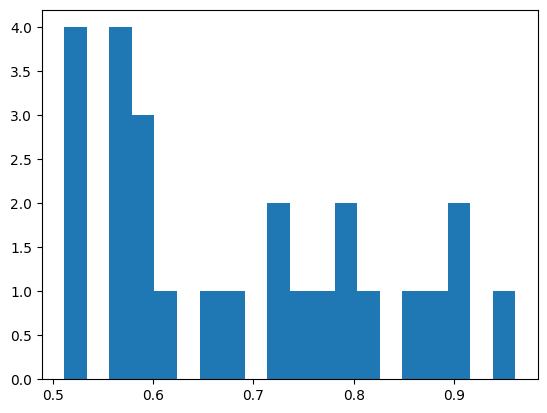

In [35]:
# check all the wrongly predicted samples and get their probabilities as a histogram
wrongly_predicted = X_test[y_test != y_pred]
wrongly_predicted_proba = model.predict_proba(wrongly_predicted)
probas = []
for sample in wrongly_predicted_proba:
    max_proba = max(sample)
    probas.append(max_proba)

plt.hist(probas, bins=20)

## Non-conformality

In [36]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

si_scores = []
# Loop through all calibration instances
for i, true_class in enumerate(y_test):
    # Get predicted probability for observed/true class
    predicted_prob = y_pred_proba[i][true_class]
    si_scores.append(1 - predicted_prob)    

# Convert to NumPy array
si_scores = np.array(si_scores)

# Show first 5 instances
si_scores[0:5]

array([0.13984051, 0.09883102, 0.44937292, 0.35917049, 0.02527757])

In [37]:
number_of_samples = len(X_test)
alpha = 0.15
qlevel = (1- alpha) * ((number_of_samples + 1) / number_of_samples)
threshold = np.percentile(si_scores, qlevel * 100)
print(f"Threshold: {threshold}")

Threshold: 0.5420896408378014


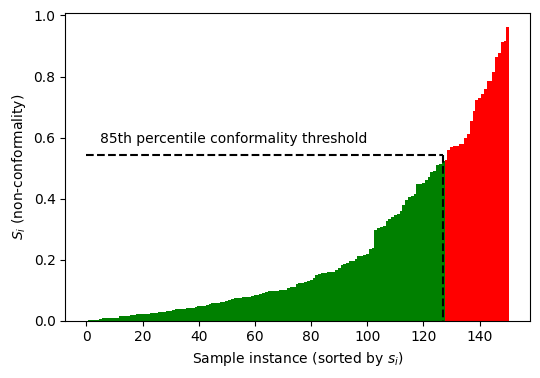

In [38]:
x = np.arange(len(si_scores)) + 1
sorted_si_scores = np.sort(si_scores)
index_of_95th_percentile = int(len(si_scores) * 0.85)

# Color by cut-off
conform = 'g' * index_of_95th_percentile
nonconform = 'r' * (len(si_scores) - index_of_95th_percentile)
color = list(conform + nonconform)

fig = plt.figure(figsize=((6,4)))
ax = fig.add_subplot()

# Add bars
ax.bar(x, sorted_si_scores, width=1.0, color = color)

# Add lines for 95th percentile
ax.plot([0, index_of_95th_percentile],[threshold, threshold], 
        c='k', linestyle='--')
ax.plot([index_of_95th_percentile, index_of_95th_percentile], [threshold, 0],
        c='k', linestyle='--')

# Add text
txt = f'{int((1-alpha) * 100)}th percentile conformality threshold'
ax.text(5, threshold + 0.04, txt)

# Add axis labels
ax.set_xlabel('Sample instance (sorted by $s_i$)')
ax.set_ylabel('$S_i$ (non-conformality)')

plt.show()

In [39]:
prediction_sets = (1 - model.predict_proba(X_test) <= threshold)

prediction_sets[:10]

array([[ True, False],
       [ True, False],
       [ True, False],
       [ True, False],
       [ True, False],
       [ True, False],
       [ True, False],
       [False,  True],
       [ True, False],
       [ True, False]])

In [40]:
# Get standard predictions
y_pred = model.predict(X_test)

class_labels = ['pass', 'fail']

# Function to get set labels
def get_prediction_set_labels(prediction_set, class_labels):
    # Get set of class labels for each instance in prediction sets
    prediction_set_labels = [
        set([class_labels[i] for i, x in enumerate(prediction_set) if x]) for prediction_set in 
        prediction_sets]
    return prediction_set_labels

# Collate predictions
results_sets = pd.DataFrame()
results_sets['observed'] = [class_labels[i] for i in y_test]
results_sets['labels'] = get_prediction_set_labels(prediction_sets, class_labels)
results_sets['classifications'] = [class_labels[i] for i in y_pred]
results_sets.head(10)

,observed,labels,classifications
0,pass,{pass},pass
1,pass,{pass},pass
2,pass,{pass},pass
3,pass,{pass},pass
4,pass,{pass},pass
5,pass,{pass},pass
6,pass,{pass},pass
7,pass,{fail},fail
8,pass,{pass},pass
9,pass,{pass},pass


In [41]:
n_classes = 2

# Get class counts
def get_class_counts(y_test):
    class_counts = []
    for i in range(n_classes):
        class_counts.append(np.sum(y_test == i))
    return class_counts

# Get coverage for each class
def get_coverage_by_class(prediction_sets, y_test):
    coverage = []
    for i in range(n_classes):
        coverage.append(np.mean(prediction_sets[y_test == i, i]))
    return coverage

# Get average set size for each class
def get_average_set_size(prediction_sets, y_test):
    average_set_size = []
    for i in range(n_classes):
        average_set_size.append(
            np.mean(np.sum(prediction_sets[y_test == i], axis=1)))
    return average_set_size     

# Get weighted coverage (weighted by class size)
def get_weighted_coverage(coverage, class_counts):
    total_counts = np.sum(class_counts)
    weighted_coverage = np.sum((coverage * class_counts) / total_counts)
    weighted_coverage = round(weighted_coverage, 3)
    return weighted_coverage

# Get weighted set_size (weighted by class size)
def get_weighted_set_size(set_size, class_counts):
    total_counts = np.sum(class_counts)
    weighted_set_size = np.sum((set_size * class_counts) / total_counts)
    weighted_set_size = round(weighted_set_size, 3)
    return weighted_set_size

In [42]:
results = pd.DataFrame(index=class_labels)
results['Class counts'] = get_class_counts(y_test)
results['Coverage'] = get_coverage_by_class(prediction_sets, y_test)
results['Average set size'] = get_average_set_size(prediction_sets, y_test)
results

,Class counts,Coverage,Average set size
pass,119,0.957983,1.02521
fail,31,0.451613,1.16129
